# Jordanian Traffic Sign Dataset Exploration


> **Reproducibility note:** Outputs are retained from the original course run. Setup logs and local paths were removed. Rerun the cells to regenerate figures with your local dataset.


In [ ]:
from pathlib import Path
import os

SEED = 42

def find_repository_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "notebooks").is_dir() and (candidate / "config").is_dir():
            return candidate
    raise FileNotFoundError(
        "Repository root not found. Start Jupyter from the repository root."
    )

project_root_override = os.getenv("JTS_PROJECT_ROOT")
REPO_ROOT = (
    Path(project_root_override).expanduser().resolve()
    if project_root_override
    else find_repository_root()
)

def configured_path(variable: str, default: Path) -> Path:
    value = os.getenv(variable)
    path = Path(value).expanduser() if value else default
    if not path.is_absolute():
        path = REPO_ROOT / path
    return path.resolve()

DATASET_ROOT = configured_path("JTS_DATASET_ROOT", REPO_ROOT / "data" / "Final_Dataset")
MODELS_DIR = REPO_ROOT / "models"
ASSETS_DIR = REPO_ROOT / "assets"
MANUAL_TEST_DIR = ASSETS_DIR / "manual-tests"

def require_directory(path: Path, purpose: str) -> Path:
    if not path.is_dir():
        raise FileNotFoundError(f"{purpose} directory not found: {path}")
    return path

def require_file(path: Path, purpose: str) -> Path:
    if not path.is_file():
        raise FileNotFoundError(f"{purpose} file not found: {path}")
    return path

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [ ]:
required_dataset_directories = [
    DATASET_ROOT / category / split
    for category in ("images", "labels")
    for split in ("train", "val", "test")
]
for directory in required_dataset_directories:
    require_directory(directory, "Dataset split")
print(f"Using dataset: {DATASET_ROOT}")


The dataset is external. Follow `data/README.md` to download it from Kaggle.

Do not place `kaggle.json` in this repository. Use Kaggle's user-level configuration or the `KAGGLE_USERNAME` and `KAGGLE_KEY` environment variables.


In [ ]:
split_sizes = {
    split: len(list((DATASET_ROOT / "images" / split).glob("*")))
    for split in ("train", "val", "test")
}
split_sizes


# Exploring Data
# 1- Number of images that contains one or more than one class

In [ ]:
def read_fil(label_directory):
    """Count images by the number of non-empty YOLO labels they contain."""
    label_directory = require_directory(Path(label_directory), "Label")
    counts = Counter()
    for label_file in sorted(label_directory.glob("*.txt")):
        with label_file.open("r", encoding="utf-8") as handle:
            object_count = sum(1 for line in handle if line.strip())
        counts[object_count] += 1
    return dict(sorted(counts.items()))


In [ ]:
def plot_fil(counts, title, color="blue"):
    items = sorted(counts.items())
    labels = [key for key, _ in items]
    values = [value for _, value in items]
    plt.bar(range(len(items)), values, tick_label=labels, color=color)
    plt.xlabel("Number of signs")
    plt.ylabel("Number of images")
    plt.title(title)
    plt.show()


{1: 6059, 3: 99, 2: 752, 4: 13}


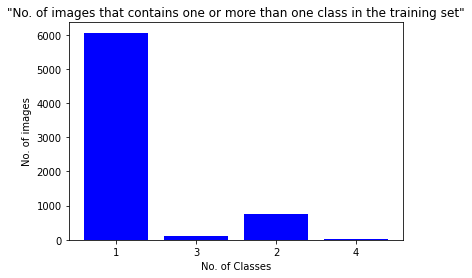

In [ ]:
train_dic = read_fil(DATASET_ROOT / "labels" / "train")
print(train_dic)
plot_fil(train_dic, "Images containing one or more signs in the training set")


{1: 1422, 2: 170, 3: 28, 4: 3}


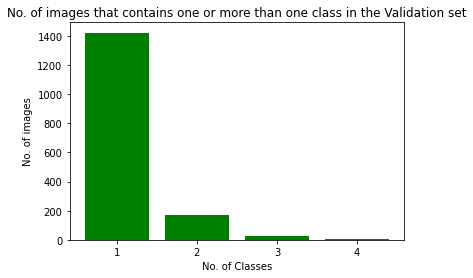

In [ ]:
val_dic = read_fil(DATASET_ROOT / "labels" / "val")
print(val_dic)
plot_fil(val_dic, "Images containing one or more signs in the validation set", "green")


{1: 619, 2: 68, 3: 11, 4: 2}


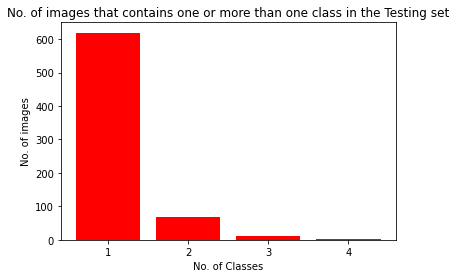

In [ ]:
test_dic = read_fil(DATASET_ROOT / "labels" / "test")
print(test_dic)
plot_fil(test_dic, "Images containing one or more signs in the test set", color="red")


# 2- Explore distribution of data based on number of image in each class 

In [ ]:
def read_count(label_directory):
    """Count images containing each class, counting a class once per image."""
    label_directory = require_directory(Path(label_directory), "Label")
    counts = Counter()
    for label_file in sorted(label_directory.glob("*.txt")):
        with label_file.open("r", encoding="utf-8") as handle:
            classes = {
                int(line.split()[0])
                for line in handle
                if line.strip()
            }
        counts.update(classes)
    return dict(sorted(counts.items()))


In [19]:
def plot_dis(dic,se,color='blue'):
    clas = list(dic.keys())
    values = list(dic.values())
    plt.bar(range(len(dic)), values, tick_label=clas,color = color)
    plt.xlabel("Classes")
    plt.ylabel("No. of images")
    plt.title(se)
    plt.show()

{2: 1059, 4: 981, 1: 1165, 5: 970, 0: 948, 3: 827, 6: 973}


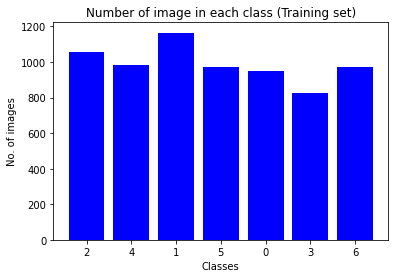

In [ ]:
train_img = read_count(DATASET_ROOT / "labels" / "train")
print(train_img)
plot_dis(train_img, "Number of images containing each class (training set)", color="blue")


{6: 223, 3: 215, 0: 222, 5: 238, 1: 249, 2: 253, 4: 223}


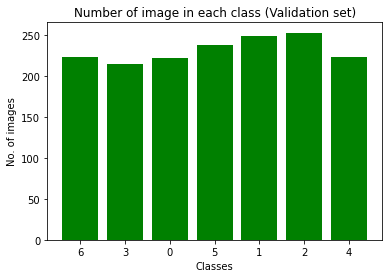

In [ ]:
valid_img = read_count(DATASET_ROOT / "labels" / "val")
print(valid_img)
plot_dis(valid_img, "Number of images containing each class (validation set)", color="green")


{1: 131, 4: 83, 6: 97, 0: 93, 2: 107, 3: 77, 5: 112}


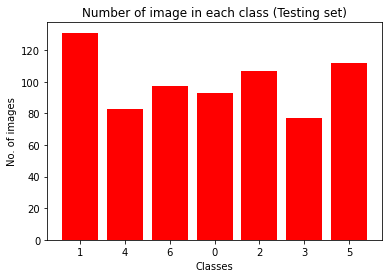

In [ ]:
test_img = read_count(DATASET_ROOT / "labels" / "test")
print(test_img)
plot_dis(test_img, "Number of images containing each class (test set)", color="red")


# Explore splitting of data

In [ ]:
def count_no(directory):
    directory = require_directory(Path(directory), "Image")
    return sum(path.is_file() for path in directory.iterdir())


In [ ]:
train_size = count_no(DATASET_ROOT / "images" / "train")
val_size = count_no(DATASET_ROOT / "images" / "val")
test_size = count_no(DATASET_ROOT / "images" / "test")


In [22]:
dic = {'Training Set':train_size,'validation_size':val_size,'Testing_size':test_size}
print(dic)
s = sum(dic.values())

{'Training Set': 6923, 'validation_size': 1623, 'Testing_size': 700}


In [ ]:
print(f"Percentage of training set: {100 * train_size / s:.2f}%")
print(f"Percentage of validation set: {100 * val_size / s:.2f}%")
print(f"Percentage of testing set: {100 * test_size / s:.2f}%")


Percentage of training set:  0.7487562189054726 %
Percentage of validation set:  0.1755353666450357 %
Percentage of testing set:  0.07570841444949167 %
